# Alzheimer MRI Project - data prep

Gets the raw Kaggle images ready for the classifier and the XAI model. Doesn't train anything, just sorts out the data.

Run it top to bottom, takes about 5 minutes. Everything gets saved into `prepped_data/`.

## Setup

In [1]:
import os
import re
import glob
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt

# where the data is - needs to be the folder with train/ val/ test/ inside it
data_folder = os.path.join("Data", "Alzheimer_Split", "Alzheimer_Split")

output_folder = "prepped_data"
os.makedirs(output_folder, exist_ok=True)

classes = ["Non_Demented", "Very_Mild_Demented", "Mild_Demented"]
random_seed = 123

## Loading the files

In [2]:
rows = []

for class_name in classes:
    for folder_name in ["train", "val", "test"]:
        folder = os.path.join(data_folder, folder_name, class_name)

        for file_path in sorted(glob.glob(os.path.join(folder, "*.jpg"))):
            file_name = os.path.basename(file_path)

            # e.g. mild_28.jpg -> 28. a few files have no number, skip those
            match = re.search(r"(\d+)", file_name)
            if match is None:
                continue

            image = Image.open(file_path)
            width, height = image.size
            colour_mode = image.mode
            image.close()

            rows.append({
                "image_path": file_path,
                "file_name": file_name,
                "file_number": int(match.group(1)),
                "class_name": class_name,
                "label": classes.index(class_name),
                "original_split": folder_name,
                "width": width,
                "height": height,
                "colour_mode": colour_mode,
            })

data = pd.DataFrame(rows)
print("images:", len(data))

images: 6333


## Checking the images

In [ ]:
print("images per class:")
for class_name in classes:
    print(class_name + ":", len(data[data["class_name"] == class_name]))

counts = data["class_name"].value_counts()
print()
print("biggest class is", round(counts.max() / counts.min(), 2), "x the smallest")

sizes and formats:
width  height  colour_mode
128    128     L              6333
dtype: int64

images per class:
Non_Demented: 3199
Very_Mild_Demented: 2239
Mild_Demented: 895

biggest class is 3.57 x the smallest
so it's not balanced - report macro-F1, not just accuracy


## Finding the patients

The dataset doesn't say which patient each image came from, which is annoying because we need that to split it properly. But the number in the filename gives it away - the images were saved one slice at a time, going through all the patients before moving to the next slice. So:

```
patient = file number % number of patients in that class
slice   = file number // number of patients in that class
```

There are 100 Non_Demented, 70 Very_Mild and 28 Mild = 198 patients, and 198 x 32 = 6336 images, which matches what we've got.

In [ ]:
patients_per_class = {"Non_Demented": 100, "Very_Mild_Demented": 70, "Mild_Demented": 28}

patient_ids = []
slice_numbers = []

for i in range(len(data)):
    row = data.iloc[i]
    n_patients = patients_per_class[row["class_name"]]

    patient_number = row["file_number"] % n_patients
    slice_number = row["file_number"] // n_patients

    # include the class in the id, patient 7 in one class isn't patient 7 in another
    patient_ids.append(row["class_name"] + "_p" + str(patient_number).zfill(3))
    slice_numbers.append(slice_number)

data["patient_id"] = patient_ids
data["slice_number"] = slice_numbers

print("patients:", data["patient_id"].nunique())
print()
for class_name in classes:
    subset = data[data["class_name"] == class_name]
    per_patient = subset.groupby("patient_id").size()
    print(class_name + ":", subset["patient_id"].nunique(), "patients")

patients: 198

Non_Demented: 100 patients, 31 to 32 slices each
Very_Mild_Demented: 70 patients, 31 to 32 slices each
Mild_Demented: 28 patients, 31 to 32 slices each


Now time to do a check and see if one patients slices all look like the same brain. Let's plot it out.

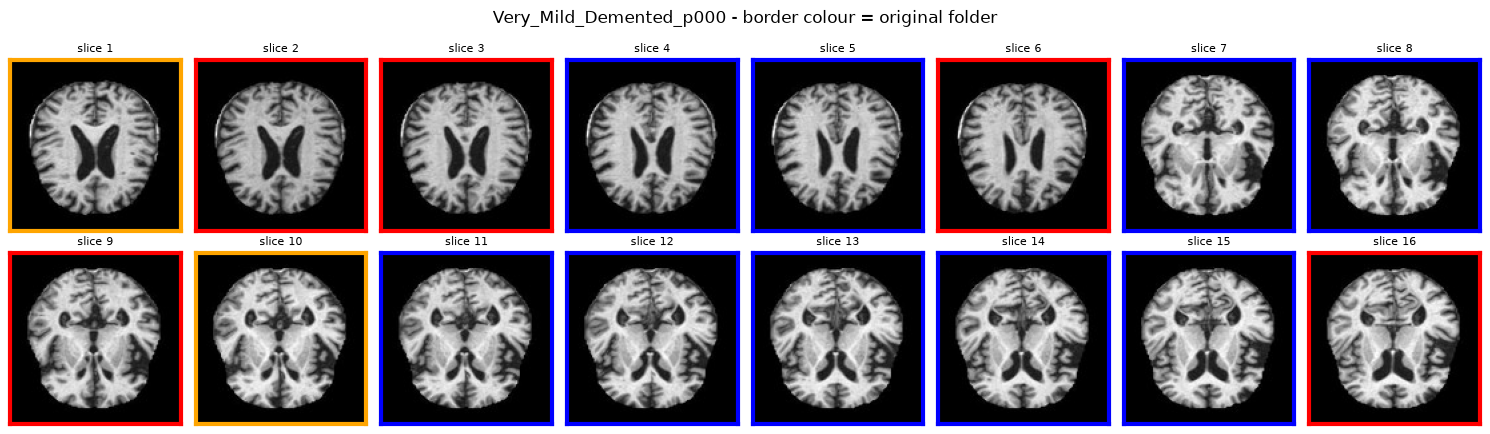

In [ ]:
example = sorted(data[data["class_name"] == "Very_Mild_Demented"]["patient_id"])[5]
patient_rows = data[data["patient_id"] == example].sort_values("slice_number")

colours = {"train": "blue", "val": "orange", "test": "red"}

figure, axes = plt.subplots(2, 8, figsize=(15, 4.5))
axes = axes.flatten()

for i in range(16):
    row = patient_rows.iloc[i]
    axes[i].imshow(Image.open(row["image_path"]), cmap="gray")
    axes[i].set_title("slice " + str(row["slice_number"]), fontsize=8)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    for side in axes[i].spines.values():
        side.set_color(colours[row["original_split"]])
        side.set_linewidth(3)

figure.suptitle(example + " - border colour = original folder")
plt.tight_layout()
plt.show()

All looks like the same brain, just different slices. All were spread across train, test and val originally but we'll redo this split to stop data leakage.

## Brain masks

This bit's for the XAI model. Grad-CAM gives you a heatmap of where the model looked, and to tell if that's sensible you need to know which pixels are actually brain and which are just black background. A heatmap pointing at the background isn't explaining anything.

In [ ]:
def make_brain_mask(image_array):
    mask = image_array > 0.235

    # drop any stray bright bits, keep the biggest blob
    blobs, n_blobs = ndimage.label(mask)
    if n_blobs > 1:
        sizes = ndimage.sum(mask, blobs, range(1, n_blobs + 1))
        mask = (blobs == np.argmax(sizes) + 1)

    # fill the dark bits inside the brain
    return ndimage.binary_fill_holes(mask)


def load_image(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

In [ ]:
all_masks = np.zeros((len(data), 128, 128), dtype=bool)
brain_fractions = []

for i in range(len(data)):
    mask = make_brain_mask(load_image(data.iloc[i]["image_path"]))
    all_masks[i] = mask
    brain_fractions.append(mask.mean())

data["brain_fraction"] = brain_fractions

made 6333 masks
brain fraction: min 0.365 max 0.507 avg 0.47
should be roughly 0.3-0.6, anything near 0 or 1 means the threshold is off


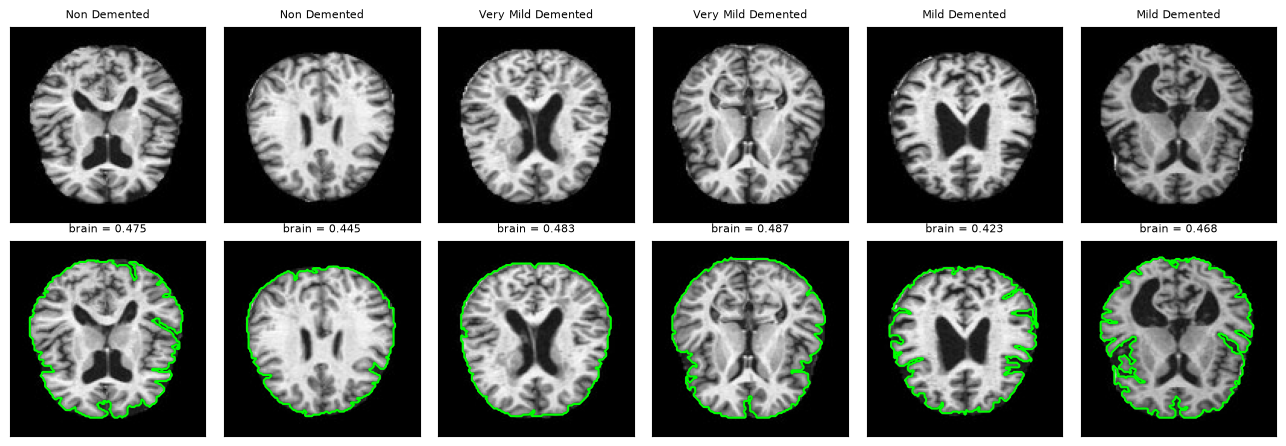

In [8]:
# eyeball a few masks
figure, axes = plt.subplots(2, 6, figsize=(13, 4.5))
column = 0

for class_name in classes:
    for i in range(2):
        row = data[data["class_name"] == class_name].sample(2, random_state=random_seed).iloc[i]
        image_array = load_image(row["image_path"])

        axes[0, column].imshow(image_array, cmap="gray")
        axes[0, column].set_title(class_name.replace("_", " "), fontsize=8)

        axes[1, column].imshow(image_array, cmap="gray")
        axes[1, column].contour(make_brain_mask(image_array), levels=[0.5], colors="lime")
        axes[1, column].set_title("brain = " + str(round(row["brain_fraction"], 3)), fontsize=8)
        column += 1

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Splitting by patient

70/15/15 split so we train on a large proportion of data and leave ample test and validation examples. This is done per class so all three classes show up everywhere. Shuffle the patients and not the images so that once a patient is in test, all their slices go to test.

Also making 5 CV folds the same way. Test is only ~30 patients so a single split is a bit noisy, the folds are more reliable.

In [9]:
random.seed(random_seed)

train_patients = []
val_patients = []
test_patients = []

for class_name in classes:
    patients = sorted(set(data[data["class_name"] == class_name]["patient_id"]))
    random.shuffle(patients)

    n_train = round(0.70 * len(patients))
    n_val = round(0.15 * len(patients))

    train_patients += patients[:n_train]
    val_patients += patients[n_train:n_train + n_val]
    test_patients += patients[n_train + n_val:]

splits = []
for patient_id in data["patient_id"]:
    if patient_id in train_patients:
        splits.append("train")
    elif patient_id in val_patients:
        splits.append("val")
    else:
        splits.append("test")

data["split"] = splits

print("patients: train", len(train_patients), "/ val", len(val_patients), "/ test", len(test_patients))
print("images:", data["split"].value_counts().to_dict())
print()
print("patients per class per split:")
print(data.groupby(["class_name", "split"])["patient_id"].nunique().unstack().to_string())

patients: train 139 / val 29 / test 30
images: {'train': 4446, 'test': 960, 'val': 927}

patients per class per split:
split               test  train  val
class_name                          
Mild_Demented          4     20    4
Non_Demented          15     70   15
Very_Mild_Demented    11     49   10


In [11]:
# 5 CV folds, also by patient
random.seed(random_seed)
fold_of_patient = {}

for class_name in classes:
    patients = sorted(set(data[data["class_name"] == class_name]["patient_id"]))
    random.shuffle(patients)
    for i in range(len(patients)):
        fold_of_patient[patients[i]] = i % 5

data["cv_fold"] = [fold_of_patient[p] for p in data["patient_id"]]

print("patients per fold:")
for fold in range(5):
    print("fold", fold, "-", data[data["cv_fold"] == fold]["patient_id"].nunique())

patients per fold:
fold 0 - 40
fold 1 - 40
fold 2 - 40
fold 3 - 39
fold 4 - 39


In [ ]:
# class weights for the loss function counted by patient
train_data = data[data["split"] == "train"]
total_patients = train_data["patient_id"].nunique()

class_weights = []
for class_name in classes:
    n = train_data[train_data["class_name"] == class_name]["patient_id"].nunique()
    class_weights.append(round(total_patients / (len(classes) * n), 4))

print("class weights:", class_weights)

class weights (same order as classes): [0.6619, 0.9456, 2.3167]


## Saving

In [ ]:
columns = ["file_name", "file_number", "class_name", "label", "patient_id",
           "slice_number", "original_split", "split", "cv_fold", "brain_fraction"]

data_final = data[columns]
data_final.to_csv(os.path.join(output_folder, "data_final.csv"), index=False)

np.savez_compressed(os.path.join(output_folder, "brain_masks.npz"), masks=all_masks)

dataset_info = {
    "number_of_images": len(data_final),
    "number_of_patients": int(data_final["patient_id"].nunique()),
    "classes": classes,
    "class_weights": class_weights,
    "images_per_class": {c: int((data_final["class_name"] == c).sum()) for c in classes},
    "patients_per_class": {c: int(data_final[data_final["class_name"] == c]["patient_id"].nunique())
                           for c in classes},
    "patients_per_split": {s: int(data_final[data_final["split"] == s]["patient_id"].nunique())
                           for s in ["train", "val", "test"]},
    "random_seed": random_seed,
}

with open(os.path.join(output_folder, "dataset_info.json"), "w") as f:
    json.dump(dataset_info, f, indent=2)

print("saved into " + output_folder + "/:")
print("data_final.csv -", len(data_final), "rows,", len(columns), "columns")
print("brain_masks.npz")
print("dataset_info.json")

saved into prepped_data/:
data_final.csv - 6333 rows, 10 columns
brain_masks.npz
dataset_info.json


## Next steps

Someone else from the group should follow on from this by doing feature engineering and augmentation

## Using it

Copy this into your notebook, you don't need to re-run the prep.

```python
import os
import pandas as pd
import numpy as np
from PIL import Image

data_folder = os.path.join("Data", "Alzheimer_Split", "Alzheimer_Split")

data_final = pd.read_csv("prepped_data/data_final.csv")
train = data_final[data_final["split"] == "train"]
val   = data_final[data_final["split"] == "val"]
test  = data_final[data_final["split"] == "test"]

def load_image(row):
    path = os.path.join(data_folder, row["original_split"], row["class_name"], row["file_name"])
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

x = load_image(train.iloc[0])
y = train.iloc[0]["label"]
```

Brain masks for the XAI side - row `i` of the array is row `i` of the csv:

```python
masks = np.load("prepped_data/brain_masks.npz")["masks"]
```